Import library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load dataset

In [3]:
df = pd.read_csv("/content/sales_data_sample.csv", encoding='latin1')
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


Check missing values

In [4]:
df.isnull().sum()

,0
ORDERNUMBER,0
QUANTITYORDERED,0
PRICEEACH,0
ORDERLINENUMBER,0
SALES,0
ORDERDATE,0
STATUS,0
QTR_ID,0
MONTH_ID,0
YEAR_ID,0


Total revenue

In [6]:
total_revenue = df["SALES"].sum()
print("Total Revenue =", total_revenue)

Total Revenue = 10032628.85


Top selling products

In [8]:
top_products = (
    df.groupby("PRODUCTLINE")["SALES"]
    .sum()
    .sort_values(ascending=False)
)
print(top_products)

PRODUCTLINE
Classic Cars        3919615.66
Vintage Cars        1903150.84
Motorcycles         1166388.34
Trucks and Buses    1127789.84
Planes               975003.57
Ships                714437.13
Trains               226243.47
Name: SALES, dtype: float64


Bar chart

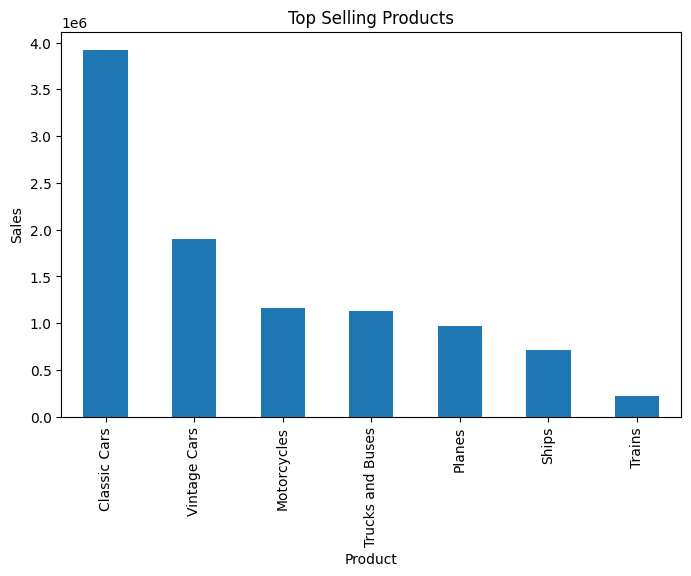

In [9]:
plt.figure(figsize=(8,5))
top_products.plot(kind="bar")
plt.title("Top Selling Products")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.show()

Category analysis

In [11]:
category_sales = df.groupby("PRODUCTLINE")["SALES"].sum()
print(category_sales)

PRODUCTLINE
Classic Cars        3919615.66
Motorcycles         1166388.34
Planes               975003.57
Ships                714437.13
Trains               226243.47
Trucks and Buses    1127789.84
Vintage Cars        1903150.84
Name: SALES, dtype: float64


Pie chart

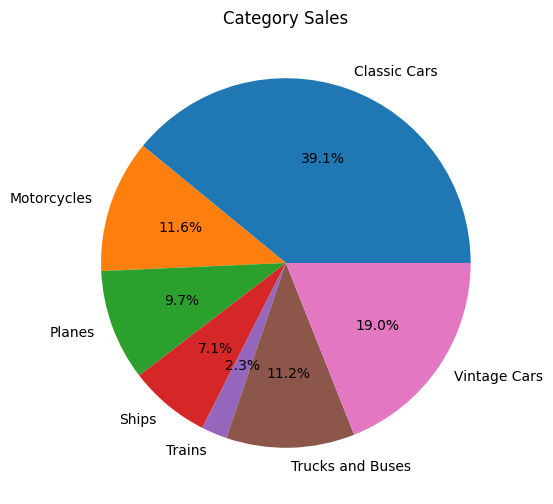

In [12]:
category_sales.plot(
    kind="pie", autopct="%1.1f%%",figsize=(6,6))
plt.title("Category Sales")
plt.ylabel("")
plt.show()

Regional performance

In [14]:
region_sales = df.groupby("TERRITORY")["SALES"].sum()
print(region_sales)

TERRITORY
APAC      746121.83
EMEA     4979272.41
Japan     455173.22
Name: SALES, dtype: float64


Graph

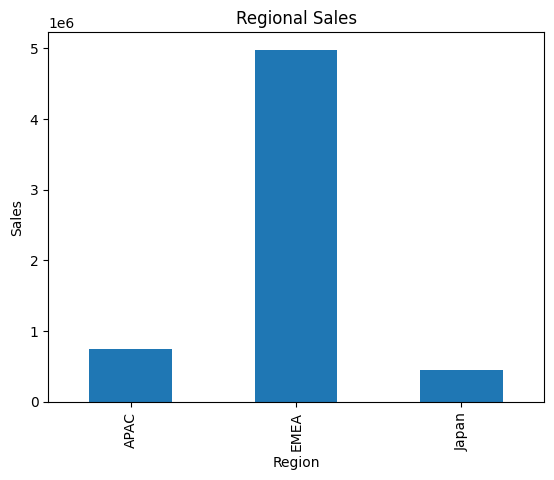

In [15]:
region_sales.plot(kind="bar")
plt.title("Regional Sales")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

Revenue trend by month

In [17]:
df["ORDERDATE"] = pd.to_datetime(df["ORDERDATE"])
df["Month"] = df["ORDERDATE"].dt.month

Monthly sales

In [19]:
monthly_sales = df.groupby("Month")["SALES"].sum()
print(monthly_sales)

Month
1      785874.44
2      810441.90
3      754501.39
4      669390.96
5      923972.56
6      454756.78
7      514875.97
8      659310.57
9      584724.27
10    1121215.22
11    2118885.67
12     634679.12
Name: SALES, dtype: float64


Line chart:

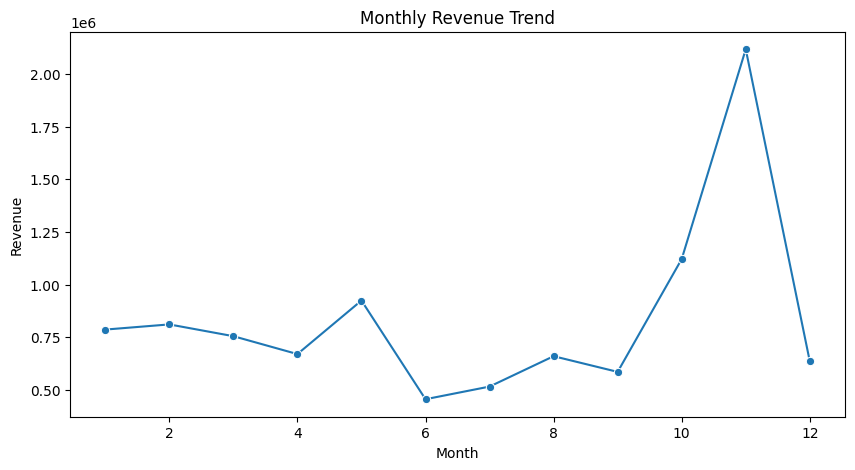

In [20]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()